# 01. 재활용품 데이터 EDA · 품질검사 · 전처리 · `processed` 생성

이 노트북의 목표는 **원본 Training / Validation 데이터가 정말 모델 학습에 사용해도 되는 상태인지 먼저 확인한 뒤**, Ultralytics YOLO Detection 모델이 바로 읽을 수 있는 `processed` 데이터셋을 만드는 것입니다.

AI나 데이터 전처리를 처음 보는 사람도 흐름을 따라갈 수 있도록 각 단계에서 다음을 설명합니다.

- 지금 왜 이 검사를 하는지
- 데이터에 어떤 문제가 있을 수 있는지
- 문제가 발견되면 어떻게 처리하는지
- 처리 후 어떤 파일이 만들어지는지
- 최종 YOLO 라벨이 어떤 의미인지

## 이 노트북이 하는 일

1. ZIP 내부 구조 확인
2. Training / Validation 이미지 수 확인
3. 클래스별 이미지 수 EDA
4. JSON 객체 라벨과 폴더 클래스의 일치 여부 확인
5. BOX / POLYGON 라벨 구조 확인
6. 이미지 해상도, 촬영 장소, 주야간, 객체 수, bbox 크기 EDA
7. 깨진 이미지 / 누락 파일 / 잘못된 bbox 검사
8. Train-Val 동일 이미지 누수 검사
9. 잘못 매칭된 샘플을 보고서에 기록하고 기본적으로 제외
10. JSON annotation → YOLO Detection txt 변환
11. `processed/images/train`, `processed/images/val`, `processed/labels/...` 생성
12. `data.yaml`, 클래스 매핑, 품질검사 CSV 생성
13. 최종 processed 데이터 재검증
14. 실제 bbox를 이미지 위에 그려 눈으로 확인

> **중요:** 이 노트북에서는 이미지 증강을 하지 않습니다.  
> 데이터 증강은 두 번째 노트북에서 실험 변수로 다룹니다. 그래야 “원본 데이터 정리”와 “성능 개선 실험”이 섞이지 않습니다.

## 0. 이번 원본 데이터에 대해 미리 확인된 특징

업로드된 `train9val2.zip`을 직접 점검했을 때 다음 특징이 있었습니다.

- 원본 이미지: **932장**
  - Training: 766장
  - Validation: 166장
- JSON 라벨도 이미지와 동일하게 932개
- Training 폴더 클래스: **86개**
  - 84개 클래스는 9장
  - `의류/기타`, `캔류/기타`는 5장
- Validation 폴더 클래스: **83개**, 각 2장
  - Training에는 있지만 Validation에 없는 클래스가 3개 있음
- 전체 원본 객체 annotation: **1,040개**
  - BOX: 1,010개
  - POLYGON: 30개
- 폴더의 목표 클래스가 JSON 객체에 실제로 존재하지 않는 이미지: **6장**
- Train / Validation 간 exact duplicate 이미지: **0건**
- JSON의 `RESOLUTION`과 실제 이미지 방향이 뒤바뀐 사례: **4건**
- 모든 이미지는 `주간` 촬영으로 기록됨

이 값들은 아래 코드에서 다시 직접 계산합니다. 즉, 하드코딩된 결과를 믿는 것이 아니라 **실제 ZIP을 다시 읽어 검증**합니다.

# 1. 필요한 라이브러리 불러오기

이 노트북은 ZIP, JSON, 이미지, 표, 그래프를 다룹니다.

- `zipfile`: ZIP을 풀지 않고 내부 파일을 읽기 위해 사용
- `json`: annotation JSON을 읽기 위해 사용
- `cv2`: 실제 이미지 크기 확인과 bbox 시각화에 사용
- `numpy`: 수치 계산
- `pandas`: EDA 표와 CSV 생성
- `matplotlib`: 그래프 생성
- `yaml`: YOLO용 `data.yaml` 생성

여기서는 **Ultralytics를 사용하지 않습니다.**  
1번 노트북의 역할은 모델 학습 이전까지의 데이터 준비입니다.

In [40]:
from __future__ import annotations

import json
import math
import random
import hashlib
import re
import shutil
import zipfile
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import yaml

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)


def set_korean_font():
    """Windows/macOS/Linux에서 설치된 한글 폰트를 가능한 범위에서 자동 선택합니다."""
    candidates = [
        "Malgun Gothic",
        "AppleGothic",
        "NanumGothic",
        "Noto Sans CJK KR",
    ]
    installed = {font.name for font in fm.fontManager.ttflist}

    for name in candidates:
        if name in installed:
            plt.rcParams["font.family"] = name
            break

    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)
print("Seed:", SEED)

OpenCV: 5.0.0
Pandas: 3.0.5
Seed: 42


# 2. 경로 설정

이번 프로젝트에서는 아래 경로 구조를 사용합니다.

```text
현재 PROJECT_ROOT
│
├─ ../../data/sample/train9val2.zip
│  └─ 원본 Training / Validation ZIP
│
├─ ../../data/processed/
│  └─ 모델 학습에 직접 사용할 전처리 결과
│
└─ ../models/yolo/01_experiment_augmentation/report/
   └─ EDA / 전처리 / 모델 실험 보고서
```

이 노트북에서 사용하는 실제 경로는 다음과 같습니다.

- `SOURCE_ZIP = PROJECT_ROOT / "../../data/sample/train9val2.zip"`
- `PROCESSED_DIR = PROJECT_ROOT / "../../data/processed"`
- `REPORT_ROOT = PROJECT_ROOT / "../models/yolo/01_experiment_augmentation/report"`
- 전처리 단계의 CSV 보고서는 `REPORT_ROOT / "preprocess"`에 저장합니다.

모든 경로에 `.resolve()`를 적용하므로 `../`, `../../`가 포함되어 있어도 실제 절대 경로로 정리됩니다.

## `OVERWRITE_PROCESSED`

- `False`: 기존 processed를 보존
- `True`: 기존 processed를 삭제하고 처음부터 다시 생성

전처리 규칙을 바꾸고 전체 데이터를 다시 만들 때는 `True`를 사용하면 됩니다.


In [41]:
PROJECT_ROOT = Path.cwd().resolve()

# ------------------------------------------------------------
# 프로젝트에서 사용할 고정 상대경로
# ------------------------------------------------------------
SOURCE_ZIP = (
    PROJECT_ROOT / "../../data/sample/train9val2.zip"
).resolve()

PROCESSED_DIR = (
    PROJECT_ROOT / "../../data/processed"
).resolve()

REPORT_ROOT = (
    PROJECT_ROOT / "../models/yolo/01_experiment_augmentation/report"
).resolve()

# 전처리/EDA에서 생성되는 CSV 보고서는 report/preprocess에 모읍니다.
REPORT_DIR = REPORT_ROOT / "preprocess"

if not SOURCE_ZIP.exists():
    raise FileNotFoundError(
        "원본 ZIP을 찾지 못했습니다.\n"
        f"예상 경로: {SOURCE_ZIP}\n"
        "현재 PROJECT_ROOT가 의도한 프로젝트 위치인지 확인하세요."
    )

OVERWRITE_PROCESSED = True

# 품질 정책
DROP_IF_TARGET_NOT_ANNOTATED = True
DROP_IF_UNKNOWN_OBJECT_EXISTS = True
KEEP_ALL_KNOWN_OBJECTS = True

print("PROJECT_ROOT  :", PROJECT_ROOT)
print("SOURCE_ZIP    :", SOURCE_ZIP)
print("PROCESSED_DIR :", PROCESSED_DIR)
print("REPORT_ROOT   :", REPORT_ROOT)
print("PREPROCESS REPORT_DIR:", REPORT_DIR)


PROJECT_ROOT  : C:\ai_challingers\recycling_ssg\ai\notebooks
SOURCE_ZIP    : C:\ai_challingers\recycling_ssg\data\sample\train9val2.zip
PROCESSED_DIR : C:\ai_challingers\recycling_ssg\data\processed
REPORT_ROOT   : C:\ai_challingers\recycling_ssg\ai\models\yolo\01_experiment_augmentation\report
PREPROCESS REPORT_DIR: C:\ai_challingers\recycling_ssg\ai\models\yolo\01_experiment_augmentation\report\preprocess


# 3. 왜 폴더 클래스와 JSON 객체 클래스를 둘 다 확인해야 할까?

원본 구조는 대략 다음과 같습니다.

```text
Training/images/고철류/프라이팬/...jpg
Training/labels/고철류/프라이팬/...json
```

폴더 경로를 보면 “이 이미지는 `고철류/프라이팬` 이미지다”라고 생각할 수 있습니다.
하지만 실제 detection 정답은 **JSON 안의 `Bounding` 객체**에 들어 있습니다.

한 이미지에는 여러 객체가 있을 수 있고, 폴더명이 잘못 분류된 경우도 있을 수 있습니다.
따라서 다음 두 개를 구분합니다.

- **목표 클래스(target class)**: 이미지가 들어 있는 폴더가 의도한 클래스
- **실제 annotation class**: JSON의 각 `Bounding.CLASS + DETAILS`

이 노트북은 폴더명을 강제로 정답으로 덮어쓰지 않습니다.  
목표 클래스가 JSON에 실제로 없다면 **의심 샘플로 기록하고 기본적으로 제외**합니다.

# 4. 대분류 이름 정규화 규칙

원본 폴더와 JSON에서 같은 의미의 대분류가 조금 다르게 적힌 사례가 있습니다.

예:

- 폴더: `나무`
- JSON: `나무류`

이것을 다른 클래스로 취급하면 안 되므로 다음처럼 이름을 통일합니다.

```text
나무류       → 나무
비닐류       → 비닐
스티로폼류   → 스티로폼
유리병류     → 유리병
페트병류     → 페트병
```

이 작업은 **라벨 의미를 바꾸는 것이 아니라 문자열 표기를 통일하는 작업**입니다.

In [42]:
CANONICAL_MAJOR = {
    "나무류": "나무",
    "비닐류": "비닐",
    "스티로폼류": "스티로폼",
    "유리병류": "유리병",
    "페트병류": "페트병",
}


def canonical_major(name: str) -> str:
    """같은 의미지만 표기가 다른 대분류 이름을 하나로 통일합니다."""
    name = str(name).strip()
    return CANONICAL_MAJOR.get(name, name)

# 5. ZIP 내부 파일 목록 확인

먼저 ZIP을 풀지 않고 내부 파일명만 읽습니다.

여기서 확인할 내용:

- Training 이미지 수
- Validation 이미지 수
- JSON 라벨 수
- 보고서 CSV가 있는지
- 이미지와 JSON의 수가 지나치게 다르지 않은지

In [43]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

with zipfile.ZipFile(SOURCE_ZIP) as zf:
    zip_members = zf.namelist()

image_members = [
    name for name in zip_members
    if Path(name).suffix.lower() in IMAGE_EXTENSIONS
]

json_members = [
    name for name in zip_members
    if Path(name).suffix.lower() == ".json"
]

csv_members = [
    name for name in zip_members
    if Path(name).suffix.lower() == ".csv"
]

print(f"ZIP 전체 entry : {len(zip_members):,}")
print(f"이미지          : {len(image_members):,}")
print(f"JSON 라벨       : {len(json_members):,}")
print(f"CSV             : {len(csv_members):,}")

print("\nZIP 상위 경로 예시")
for name in zip_members[:30]:
    print("-", name)

ZIP 전체 entry : 4,090
이미지          : 932
JSON 라벨       : 932
CSV             : 6

ZIP 상위 경로 예시
- Training/
- Training/images/
- Training/images/고철류/
- Training/images/고철류/고철/
- Training/images/고철류/고철/12_X001_C024_1123/
- Training/images/고철류/고철/12_X001_C024_1123/12_X001_C024_1123_1.jpg
- Training/images/고철류/고철/12_X002_C023_1211/
- Training/images/고철류/고철/12_X002_C023_1211/12_X002_C023_1211_4.jpg
- Training/images/고철류/고철/12_X003_C044_1105/
- Training/images/고철류/고철/12_X003_C044_1105/12_X003_C044_1105_0.jpg
- Training/images/고철류/고철/12_X004_C055_1027/
- Training/images/고철류/고철/12_X004_C055_1027/12_X004_C055_1027_4.jpg
- Training/images/고철류/고철/12_X006_C195_1117/
- Training/images/고철류/고철/12_X006_C195_1117/12_X006_C195_1117_3.jpg
- Training/images/고철류/고철/12_X009_C024_1214/
- Training/images/고철류/고철/12_X009_C024_1214/12_X009_C024_1214_5.jpg
- Training/images/고철류/고철/12_X010_C193_1208/
- Training/images/고철류/고철/12_X010_C193_1208/12_X010_C193_1208_4.jpg
- Training/images/고철류/고철/12_X046_C900_1218/
- Tra

# 6. 폴더 기준 클래스 목록 만들기

우리 프로젝트에서 학습할 클래스 체계는 **Training 폴더에 실제로 존재하는 대분류/소분류 조합**을 기준으로 고정합니다.

예를 들어 `고철류/주전자`와 `도기류/주전자`는 소분류 이름이 같더라도 다른 클래스입니다.

그래서 클래스명을 단순히 `주전자`라고 만들지 않고 다음처럼 만듭니다.

```text
고철류/주전자
도기류/주전자
```

이 방식은 서로 다른 대분류의 같은 소분류 이름이 충돌하는 것을 막아줍니다.

In [44]:
def parse_folder_target(member_name: str):
    """
    ZIP 경로에서 split / 대분류 / 소분류를 읽습니다.

    예상 구조:
    Training/images/대분류/소분류/scene/file.jpg
    Validation/images/대분류/소분류/scene/file.jpg
    """
    parts = Path(member_name).parts

    if len(parts) < 5:
        raise ValueError(f"예상보다 짧은 경로입니다: {member_name}")

    split = parts[0]
    major = canonical_major(parts[2])
    detail = parts[3]

    return split, major, detail


training_class_pairs = set()

for member in image_members:
    split, major, detail = parse_folder_target(member)

    if split == "Training":
        training_class_pairs.add((major, detail))

CLASS_PAIRS = sorted(training_class_pairs)
CLASS_NAMES = [f"{major}/{detail}" for major, detail in CLASS_PAIRS]
CLASS_TO_ID = {class_name: class_id for class_id, class_name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {class_id: class_name for class_name, class_id in CLASS_TO_ID.items()}

print("Training 기준 최종 클래스 수:", len(CLASS_NAMES))

display(
    pd.DataFrame({
        "class_id": range(len(CLASS_NAMES)),
        "class_name": CLASS_NAMES,
    })
)

Training 기준 최종 클래스 수: 86


,class_id,class_name
0,0,고철류/고철
1,1,고철류/골프채
2,2,고철류/기타
3,3,고철류/비철금속
4,4,고철류/전기프라이팬
5,5,고철류/주전자
6,6,고철류/철옷걸이
7,7,고철류/프라이팬
8,8,나무/기타
9,9,나무/나무행거


# 7. 폴더 기준 이미지 수 EDA

먼저 annotation 내용을 보기 전에 폴더만 기준으로 클래스별 이미지 수를 셉니다.

이 표는 “데이터를 어떤 의도로 수집했는가”를 보여줍니다.
반면 나중에 계산하는 객체 수는 “실제 JSON annotation에는 무엇이 들어 있는가”를 보여줍니다.

두 값이 다를 수 있다는 것이 중요합니다.

In [45]:
folder_rows = []

for member in image_members:
    split, major, detail = parse_folder_target(member)

    folder_rows.append({
        "split": split,
        "major": major,
        "detail": detail,
        "class_name": f"{major}/{detail}",
        "image_member": member,
    })

folder_df = pd.DataFrame(folder_rows)

folder_support = (
    folder_df
    .groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Training", "Validation"], fill_value=0)
    .sort_index()
)

folder_support["total"] = folder_support["Training"] + folder_support["Validation"]

display(folder_support)

print("Training 클래스 수:", int((folder_support["Training"] > 0).sum()))
print("Validation 클래스 수:", int((folder_support["Validation"] > 0).sum()))
print("Validation에 없는 Training 클래스 수:", int((folder_support["Validation"] == 0).sum()))

split,Training,Validation,total
class_name,,,
고철류/고철,9,2,11
고철류/골프채,9,2,11
고철류/기타,9,2,11
고철류/비철금속,9,2,11
고철류/전기프라이팬,9,2,11
고철류/주전자,9,2,11
고철류/철옷걸이,9,2,11
고철류/프라이팬,9,2,11
나무/기타,9,2,11


Training 클래스 수: 86
Validation 클래스 수: 83
Validation에 없는 Training 클래스 수: 3


In [46]:
for split in ["Training", "Validation"]:
    counts = folder_support.loc[folder_support[split] > 0, split]

    print(f"[{split}] 클래스별 이미지 개수 분포")
    display(counts.value_counts().sort_index().rename("class_count").to_frame())

[Training] 클래스별 이미지 개수 분포


,class_count
Training,
5,2
9,84


[Validation] 클래스별 이미지 개수 분포


,class_count
Validation,
2,83


## 클래스 균형 그래프 읽는 법

가로축은 클래스이고 세로축은 이미지 수입니다.

모든 막대 높이가 비슷하면 이미지 단위 클래스 균형이 비교적 좋습니다.
하지만 **이미지 수가 같다고 객체 수까지 같은 것은 아닙니다.**
한 이미지에 여러 객체가 annotation되어 있을 수 있기 때문입니다.

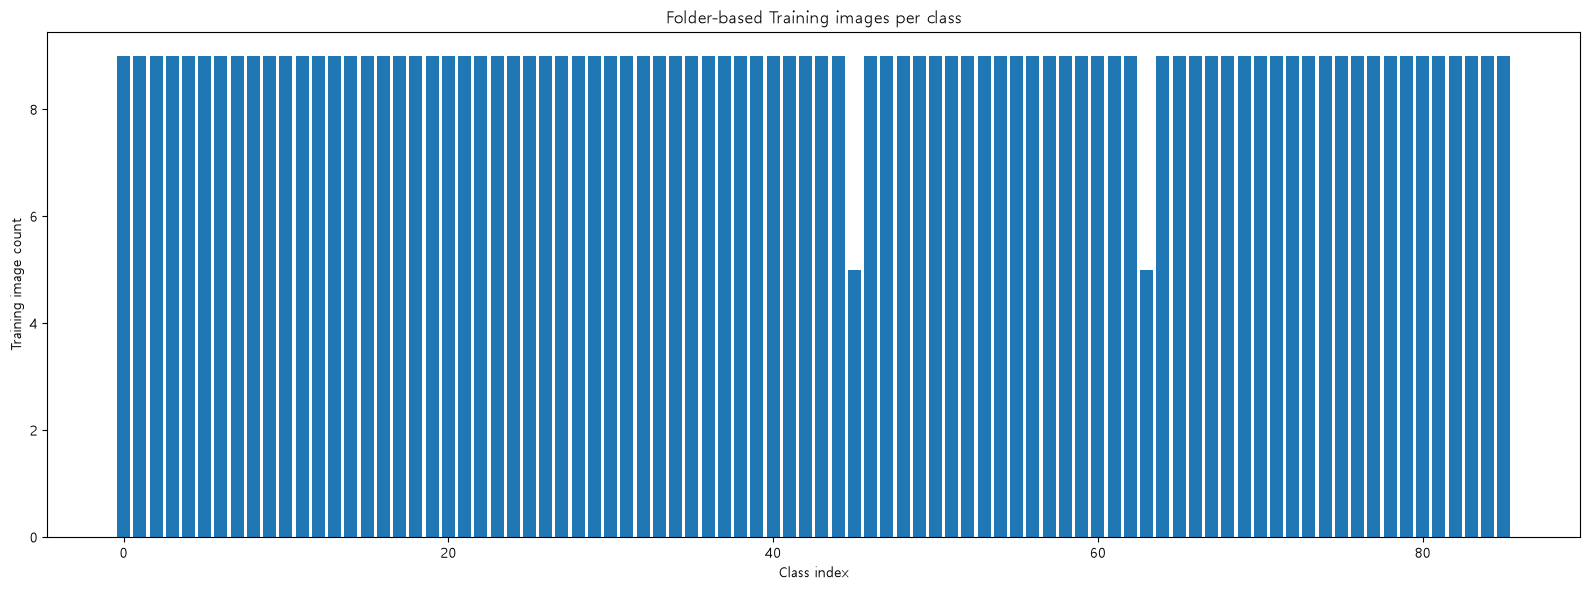

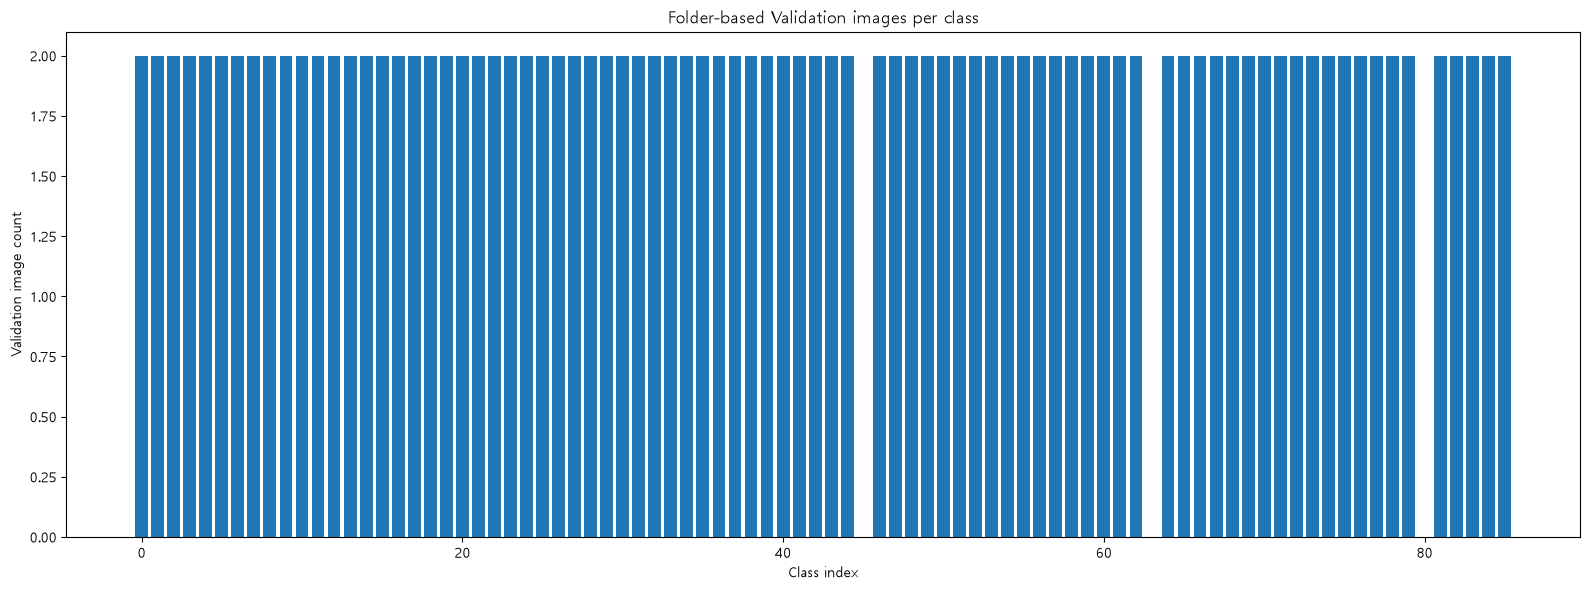

In [47]:
plot_support = folder_support.reset_index()

plt.figure(figsize=(16, 6))
plt.bar(np.arange(len(plot_support)), plot_support["Training"])
plt.xlabel("Class index")
plt.ylabel("Training image count")
plt.title("Folder-based Training images per class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
plt.bar(np.arange(len(plot_support)), plot_support["Validation"])
plt.xlabel("Class index")
plt.ylabel("Validation image count")
plt.title("Folder-based Validation images per class")
plt.tight_layout()
plt.show()

# 8. JSON과 이미지 연결 규칙

원본 ZIP에서는 이미지와 JSON이 같은 구조를 사용하고 `images` / `labels`만 다릅니다.

```text
Training/images/고철류/프라이팬/.../sample.jpg
Training/labels/고철류/프라이팬/.../sample.json
```

아래 함수는 JSON 경로를 이미지 경로로 바꿉니다.

In [48]:
def json_to_image_member(json_member: str) -> str:
    """JSON ZIP 경로를 대응 이미지 ZIP 경로로 변환합니다."""
    without_ext = json_member.rsplit(".", 1)[0]
    return without_ext.replace("/labels/", "/images/") + ".jpg"

# 9. BOX와 POLYGON을 Detection bbox로 읽는 함수

YOLO Detection은 직사각형 bounding box가 필요합니다.

## BOX

원본에 `x1, y1, x2, y2`가 있으면 그대로 사용할 수 있습니다.

## POLYGON

일부 annotation은 객체 외곽을 여러 점으로 그린 polygon입니다.
현재 프로젝트는 **segmentation이 아니라 object detection**을 학습하므로 polygon의 모든 점을 포함하는 가장 작은 축 정렬 직사각형을 만듭니다.

즉,

```text
polygon의 최소 x → x1
polygon의 최소 y → y1
polygon의 최대 x → x2
polygon의 최대 y → y2
```

이렇게 하면 polygon 정보 일부는 단순화되지만 Detection bbox로 일관되게 학습할 수 있습니다.

In [49]:
def polygon_points_to_xyxy(polygon_points):
    points = []

    for item in polygon_points or []:
        if not item:
            continue

        raw_value = next(iter(item.values()))
        x, y = str(raw_value).split(",")
        points.append((float(x), float(y)))

    if not points:
        raise ValueError("PolygonPoint가 비어 있습니다.")

    xs = [point[0] for point in points]
    ys = [point[1] for point in points]

    return min(xs), min(ys), max(xs), max(ys)


def bounding_to_xyxy(bounding: dict):
    """Bounding 하나를 x1,y1,x2,y2로 변환하고 원본 geometry 종류도 반환합니다."""
    if all(key in bounding for key in ("x1", "y1", "x2", "y2")):
        return (
            float(bounding["x1"]),
            float(bounding["y1"]),
            float(bounding["x2"]),
            float(bounding["y2"]),
            "BOX",
        )

    if bounding.get("PolygonPoint"):
        x1, y1, x2, y2 = polygon_points_to_xyxy(bounding["PolygonPoint"])
        return x1, y1, x2, y2, "POLYGON->BOX"

    raise ValueError("BOX 좌표도 PolygonPoint도 없는 annotation입니다.")

# 10. 이미지 실제 해상도와 JSON RESOLUTION 읽기

bbox 좌표 정규화에는 이미지의 가로/세로 크기가 꼭 필요합니다.

원본 JSON에는 `RESOLUTION`도 있지만, 메타데이터는 잘못될 수 있습니다.
따라서 이 노트북은 **OpenCV로 실제 이미지를 디코딩해서 얻은 width/height를 정답으로 사용**합니다.

JSON 해상도는 품질검사 참고용으로만 비교합니다.

In [50]:
def parse_resolution(value):
    """'1920*1080', '1920x1080' 같은 문자열을 (width, height)로 변환합니다."""
    match = re.match(r"\s*(\d+)\s*[xX*]\s*(\d+)\s*", str(value))

    if not match:
        return None, None

    return int(match.group(1)), int(match.group(2))


def decode_image_bytes(raw_bytes: bytes):
    """ZIP에서 읽은 JPG bytes를 OpenCV 이미지로 디코딩합니다."""
    array = np.frombuffer(raw_bytes, dtype=np.uint8)
    return cv2.imdecode(array, cv2.IMREAD_COLOR)

# 11. 원본 전체 품질검사 + EDA 테이블 만들기

이 셀이 원본 ZIP을 가장 꼼꼼하게 읽는 핵심 단계입니다.

각 이미지마다 다음을 기록합니다.

- split
- 폴더 목표 클래스
- 실제 이미지 width / height
- JSON RESOLUTION
- 실내/실외
- 주간/야간
- 객체 수
- JSON에 목표 클래스가 존재하는지
- 학습 대상 86개 밖의 객체가 존재하는지
- 이미지 SHA-1 hash

각 객체마다 다음을 기록합니다.

- JSON의 실제 클래스
- BOX인지 POLYGON인지
- bbox 좌표
- bbox 면적이 전체 이미지에서 차지하는 비율
- bbox 가로/세로 비율
- 폴더 목표 클래스와 같은 객체인지

In [51]:
image_rows = []
object_rows = []
issue_rows = []

known_class_pairs = set(CLASS_PAIRS)
zip_member_set = set(zip_members)

with zipfile.ZipFile(SOURCE_ZIP) as zf:
    for json_member in sorted(json_members):
        parts = Path(json_member).parts
        split = parts[0]
        folder_major = canonical_major(parts[2])
        folder_detail = parts[3]
        target_pair = (folder_major, folder_detail)
        target_class_name = f"{folder_major}/{folder_detail}"

        payload = json.load(zf.open(json_member))
        image_member = json_to_image_member(json_member)

        if image_member not in zip_member_set:
            issue_rows.append({
                "issue_type": "missing_image",
                "split": split,
                "json_member": json_member,
                "image_member": image_member,
                "detail": "JSON에 대응되는 이미지 파일이 ZIP에 없습니다.",
            })
            continue

        raw_image = zf.read(image_member)
        sha1 = hashlib.sha1(raw_image).hexdigest()
        image = decode_image_bytes(raw_image)

        if image is None:
            issue_rows.append({
                "issue_type": "decode_failed",
                "split": split,
                "json_member": json_member,
                "image_member": image_member,
                "detail": "OpenCV가 이미지를 디코딩하지 못했습니다.",
            })
            continue

        height, width = image.shape[:2]
        meta_width, meta_height = parse_resolution(payload.get("RESOLUTION", ""))

        if (meta_width, meta_height) != (width, height):
            issue_rows.append({
                "issue_type": "resolution_metadata_mismatch",
                "split": split,
                "json_member": json_member,
                "image_member": image_member,
                "detail": f"actual={width}x{height}, metadata={meta_width}x{meta_height}",
            })

        bounds = payload.get("Bounding") or []
        actual_pairs = []
        unknown_pairs = []
        valid_object_count = 0

        for object_index, bounding in enumerate(bounds):
            major = canonical_major(bounding.get("CLASS", "UNKNOWN"))
            detail = str(bounding.get("DETAILS", "UNKNOWN")).strip()
            object_pair = (major, detail)
            class_name = f"{major}/{detail}"
            actual_pairs.append(object_pair)

            if object_pair not in known_class_pairs:
                unknown_pairs.append(object_pair)

            try:
                x1, y1, x2, y2, geometry = bounding_to_xyxy(bounding)

                # 실제 이미지 범위를 넘어간 좌표는 이미지 경계로 잘라줍니다.
                clipped_x1 = float(np.clip(x1, 0, width))
                clipped_x2 = float(np.clip(x2, 0, width))
                clipped_y1 = float(np.clip(y1, 0, height))
                clipped_y2 = float(np.clip(y2, 0, height))

                if clipped_x2 <= clipped_x1 or clipped_y2 <= clipped_y1:
                    raise ValueError("clip 후 bbox의 width 또는 height가 0 이하입니다.")

                bbox_width = clipped_x2 - clipped_x1
                bbox_height = clipped_y2 - clipped_y1
                bbox_area_ratio = (bbox_width * bbox_height) / (width * height)
                bbox_aspect_ratio = bbox_width / bbox_height

                valid_object_count += 1

                object_rows.append({
                    "split": split,
                    "image_member": image_member,
                    "json_member": json_member,
                    "object_index": object_index,
                    "folder_target_class": target_class_name,
                    "object_major": major,
                    "object_detail": detail,
                    "object_class": class_name,
                    "is_target_object": object_pair == target_pair,
                    "is_known_training_class": object_pair in known_class_pairs,
                    "source_geometry": geometry,
                    "x1": clipped_x1,
                    "y1": clipped_y1,
                    "x2": clipped_x2,
                    "y2": clipped_y2,
                    "bbox_width": bbox_width,
                    "bbox_height": bbox_height,
                    "bbox_area_ratio": bbox_area_ratio,
                    "bbox_aspect_ratio": bbox_aspect_ratio,
                })

            except Exception as error:
                issue_rows.append({
                    "issue_type": "invalid_annotation",
                    "split": split,
                    "json_member": json_member,
                    "image_member": image_member,
                    "detail": f"object_index={object_index}, error={error!r}",
                })

        target_is_annotated = target_pair in actual_pairs

        if not target_is_annotated:
            issue_rows.append({
                "issue_type": "folder_target_not_in_json",
                "split": split,
                "json_member": json_member,
                "image_member": image_member,
                "detail": (
                    f"folder target={target_class_name}, "
                    f"json objects={[f'{m}/{d}' for m, d in actual_pairs]}"
                ),
            })

        if unknown_pairs:
            issue_rows.append({
                "issue_type": "unknown_object_class",
                "split": split,
                "json_member": json_member,
                "image_member": image_member,
                "detail": f"unknown objects={[f'{m}/{d}' for m, d in unknown_pairs]}",
            })

        image_rows.append({
            "split": split,
            "image_member": image_member,
            "json_member": json_member,
            "image_name": Path(image_member).name,
            "folder_major": folder_major,
            "folder_detail": folder_detail,
            "folder_target_class": target_class_name,
            "width": width,
            "height": height,
            "meta_width": meta_width,
            "meta_height": meta_height,
            "resolution_match": (meta_width, meta_height) == (width, height),
            "place": payload.get("PLACE"),
            "day_night": payload.get("DAY/NIGHT"),
            "bounding_count_declared": int(payload.get("BoundingCount", len(bounds))),
            "bounding_count_json": len(bounds),
            "valid_object_count": valid_object_count,
            "target_is_annotated": target_is_annotated,
            "unknown_object_count": len(unknown_pairs),
            "sha1": sha1,
        })

image_df = pd.DataFrame(image_rows)
object_df = pd.DataFrame(object_rows)
issue_df = pd.DataFrame(issue_rows)

print("image_df rows :", len(image_df))
print("object_df rows:", len(object_df))
print("issue_df rows :", len(issue_df))

image_df rows : 932
object_df rows: 1040
issue_df rows : 13


# 12. 원본 데이터 전체 요약

여기서는 가장 기본적인 규모를 확인합니다.

`objects`는 “이미지 폴더 수”가 아니라 JSON 안에서 읽은 실제 객체 annotation 수입니다.

In [52]:
raw_summary = (
    image_df
    .groupby("split")
    .agg(
        images=("image_member", "count"),
        valid_objects=("valid_object_count", "sum"),
        target_mismatch_images=("target_is_annotated", lambda s: int((~s).sum())),
        resolution_metadata_mismatches=("resolution_match", lambda s: int((~s).sum())),
    )
    .reindex(["Training", "Validation"])
)

display(raw_summary)

geometry_summary = object_df["source_geometry"].value_counts().rename("objects").to_frame()
display(geometry_summary)

,images,valid_objects,target_mismatch_images,resolution_metadata_mismatches
split,,,,
Training,766,861,5,4
Validation,166,179,1,0


,objects
source_geometry,
BOX,1010
POLYGON->BOX,30


# 13. 데이터 품질 이슈 목록

`issue_type`별 의미:

- `folder_target_not_in_json`: 폴더가 의도한 클래스가 JSON 객체에 없음
- `unknown_object_class`: Training 클래스 체계 86개 밖의 객체가 annotation됨
- `resolution_metadata_mismatch`: JSON의 해상도 문자열과 실제 이미지 크기가 다름
- `invalid_annotation`: bbox 좌표가 잘못되었거나 해석할 수 없음
- `missing_image`: JSON은 있는데 대응 이미지가 없음
- `decode_failed`: 이미지 파일이 손상되어 OpenCV가 읽지 못함

**해상도 metadata mismatch는 곧바로 이미지 삭제 사유가 아닙니다.**  
실제 이미지를 정상적으로 읽을 수 있다면 실제 width/height를 사용해 안전하게 변환할 수 있습니다.

In [53]:
if len(issue_df):
    display(issue_df["issue_type"].value_counts().rename("count").to_frame())
    display(issue_df.sort_values(["issue_type", "split"]))
else:
    print("발견된 품질 이슈가 없습니다.")

,count
issue_type,
folder_target_not_in_json,6
resolution_metadata_mismatch,4
unknown_object_class,3


,issue_type,split,json_member,image_member,detail
0,folder_target_not_in_json,Training,Training/labels/도기류/기타/14_X044_C045_0128/14_X0...,Training/images/도기류/기타/14_X044_C045_0128/14_X0...,"folder target=도기류/기타, json objects=['도기류/그릇류',..."
2,folder_target_not_in_json,Training,Training/labels/도기류/기타/14_X047_C045_0128/14_X0...,Training/images/도기류/기타/14_X047_C045_0128/14_X0...,"folder target=도기류/기타, json objects=['도기류/그릇류',..."
4,folder_target_not_in_json,Training,Training/labels/도기류/기타/14_X051_C045_0128/14_X0...,Training/images/도기류/기타/14_X051_C045_0128/14_X0...,"folder target=도기류/기타, json objects=['도기류/그릇류',..."
6,folder_target_not_in_json,Training,Training/labels/비닐/기타/15_X071_C205_1206/15_X07...,Training/images/비닐/기타/15_X071_C205_1206/15_X07...,"folder target=비닐/기타, json objects=['비닐/과자봉지']"
7,folder_target_not_in_json,Training,Training/labels/비닐/기타/15_X071_C205_1206/15_X07...,Training/images/비닐/기타/15_X071_C205_1206/15_X07...,"folder target=비닐/기타, json objects=['비닐/과자봉지']"
12,folder_target_not_in_json,Validation,Validation/labels/도기류/병/14_X004_C163_1203/14_X...,Validation/images/도기류/병/14_X004_C163_1203/14_X...,"folder target=도기류/병, json objects=['도기류/그릇류']"
8,resolution_metadata_mismatch,Training,Training/labels/캔류/음료수캔/22_X017_C509_0512/22_X...,Training/images/캔류/음료수캔/22_X017_C509_0512/22_X...,"actual=1440x1921, metadata=1921x1440"
9,resolution_metadata_mismatch,Training,Training/labels/페트병/기타/23_X004_C509_0511/23_X0...,Training/images/페트병/기타/23_X004_C509_0511/23_X0...,"actual=1440x1921, metadata=1921x1440"
10,resolution_metadata_mismatch,Training,Training/labels/페트병/기타/23_X013_C509_0511/23_X0...,Training/images/페트병/기타/23_X013_C509_0511/23_X0...,"actual=1440x1921, metadata=1921x1440"
11,resolution_metadata_mismatch,Training,Training/labels/페트병/기타/23_X020_C509_0511/23_X0...,Training/images/페트병/기타/23_X020_C509_0511/23_X0...,"actual=1440x1921, metadata=1921x1440"


# 14. 폴더-JSON 불일치 샘플만 따로 확인

이 항목은 특히 중요합니다.

예를 들어 폴더는 `도기류/기타`인데 JSON 안에는 `도기류/그릇류`와 `전자제품/기타`만 있다면,
폴더 이름을 근거로 `도기류/기타` bbox를 만들어서는 안 됩니다.
실제로 없는 정답을 조작하는 것이 되기 때문입니다.

따라서 기본 정책은 **해당 이미지를 processed에서 제외**하는 것입니다.

In [54]:
mismatch_df = issue_df[
    issue_df["issue_type"].eq("folder_target_not_in_json")
].copy() if len(issue_df) else pd.DataFrame()

print("폴더 목표 클래스가 JSON에 없는 이미지 수:", len(mismatch_df))

if len(mismatch_df):
    display(mismatch_df[["split", "image_member", "detail"]])

폴더 목표 클래스가 JSON에 없는 이미지 수: 6


,split,image_member,detail
0,Training,Training/images/도기류/기타/14_X044_C045_0128/14_X0...,"folder target=도기류/기타, json objects=['도기류/그릇류',..."
2,Training,Training/images/도기류/기타/14_X047_C045_0128/14_X0...,"folder target=도기류/기타, json objects=['도기류/그릇류',..."
4,Training,Training/images/도기류/기타/14_X051_C045_0128/14_X0...,"folder target=도기류/기타, json objects=['도기류/그릇류',..."
6,Training,Training/images/비닐/기타/15_X071_C205_1206/15_X07...,"folder target=비닐/기타, json objects=['비닐/과자봉지']"
7,Training,Training/images/비닐/기타/15_X071_C205_1206/15_X07...,"folder target=비닐/기타, json objects=['비닐/과자봉지']"
12,Validation,Validation/images/도기류/병/14_X004_C163_1203/14_X...,"folder target=도기류/병, json objects=['도기류/그릇류']"


# 15. 촬영 환경 EDA: 주간/야간, 실내/실외

모델은 학습 데이터에서 본 환경에 강하고, 보지 못한 환경에는 약할 수 있습니다.

예를 들어 학습 데이터가 모두 주간이라면 실제 서비스에서 밤에 촬영한 사진에 대한 성능은 별도로 검증해야 합니다.
이미지 증강으로 어둡게 만드는 것은 도움이 될 수 있지만 **실제 야간 데이터 자체를 완전히 대체하지는 못합니다.**

In [55]:
place_table = (
    image_df.groupby(["split", "place"])
    .size()
    .rename("images")
    .reset_index()
)

day_table = (
    image_df.groupby(["split", "day_night"])
    .size()
    .rename("images")
    .reset_index()
)

display(place_table)
display(day_table)

,split,place,images
0,Training,실내,46
1,Training,실외,720
2,Validation,실내,15
3,Validation,실외,151


,split,day_night,images
0,Training,주간,766
1,Validation,주간,166


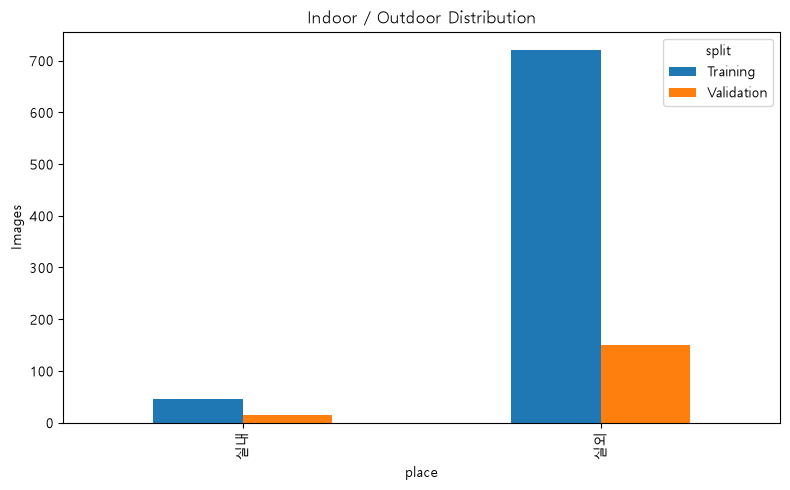

In [56]:
place_pivot = (
    place_table
    .pivot(index="place", columns="split", values="images")
    .fillna(0)
)

place_pivot.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Images")
plt.title("Indoor / Outdoor Distribution")
plt.tight_layout()
plt.show()

# 16. 이미지 해상도 EDA

YOLO는 학습 중 `imgsz` 크기로 입력을 조정하기 때문에 원본을 미리 모두 640×640으로 저장할 필요가 없습니다.

오히려 지금 단계에서 JPG를 다시 리사이즈·저장하면:

- 한 번 더 압축되어 화질이 손실될 수 있고
- 원본 비율과 정보를 불필요하게 바꿀 수 있으며
- 이후 다른 `imgsz` 실험을 하기 어려워집니다.

따라서 processed에는 **원본 이미지 bytes를 그대로 복사**합니다.

,width,height,images
8,1920,1440,316
6,1920,1080,190
13,1921,1440,136
5,1440,1921,67
10,1921,1080,66
9,1920,1920,34
11,1921,1081,23
4,1440,1920,23
18,2221,1080,17
1,1080,1921,16


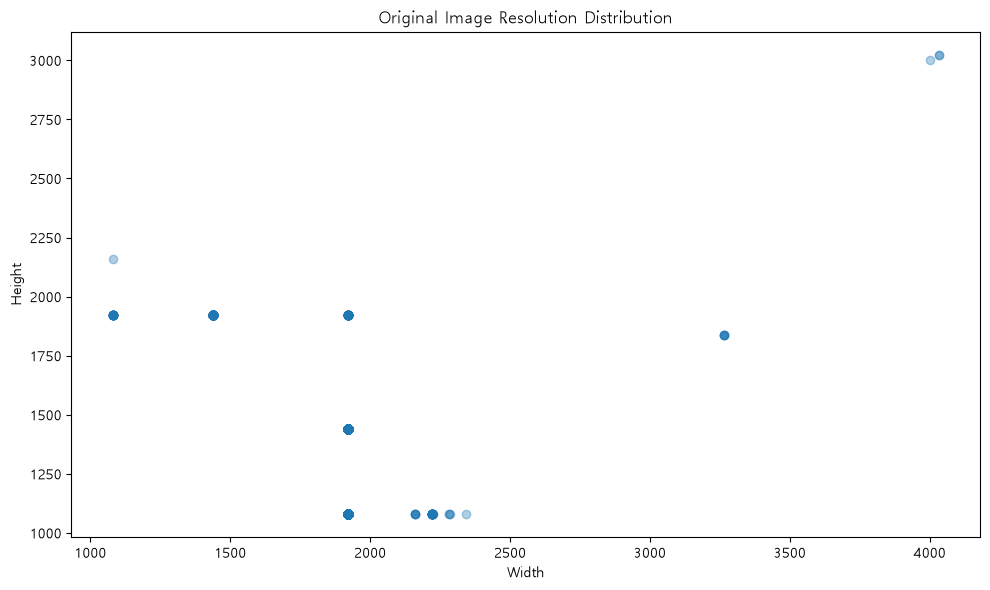

In [57]:
resolution_df = (
    image_df.groupby(["width", "height"])
    .size()
    .rename("images")
    .reset_index()
    .sort_values("images", ascending=False)
)

display(resolution_df.head(30))

plt.figure(figsize=(10, 6))
plt.scatter(image_df["width"], image_df["height"], alpha=0.35)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Original Image Resolution Distribution")
plt.tight_layout()
plt.show()

# 17. 이미지당 객체 수 EDA

폴더가 클래스별로 이미지를 수집했다고 해도 한 이미지에 다른 객체가 함께 들어 있을 수 있습니다.

Detection에서는 이미지 안에 존재하는 **학습 대상 객체를 가능한 한 모두 annotation하는 것이 중요**합니다.
그렇지 않으면 실제 객체를 background라고 잘못 가르칠 수 있기 때문입니다.

따라서 폴더 목표 클래스가 정상적으로 존재하는 이미지에서는 기본적으로 JSON에 있는 **86개 학습 대상 클래스의 모든 객체를 유지**합니다.

,images
valid_object_count,
1,827
2,102
3,3


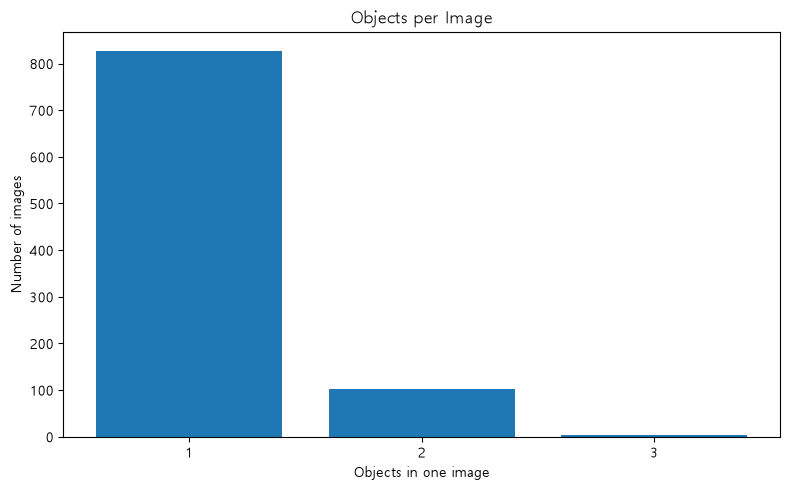

In [58]:
objects_per_image = image_df["valid_object_count"].value_counts().sort_index()

display(objects_per_image.rename("images").to_frame())

plt.figure(figsize=(8, 5))
plt.bar(objects_per_image.index.astype(str), objects_per_image.values)
plt.xlabel("Objects in one image")
plt.ylabel("Number of images")
plt.title("Objects per Image")
plt.tight_layout()
plt.show()

# 18. bbox 크기 EDA

`bbox_area_ratio`는 객체 bbox 면적을 전체 이미지 면적으로 나눈 값입니다.

예:

- 0.01 → 이미지의 약 1% 면적
- 0.25 → 이미지의 약 25% 면적

작은 객체가 많으면 `imgsz`, scale 증강, mosaic 등에 대한 반응이 달라질 수 있습니다.
이 분포는 두 번째 증강 실험을 해석할 때도 중요한 참고 자료입니다.

,bbox_area_ratio
count,1040.000000
mean,0.185998
std,0.134271
min,0.002598
1%,0.008984
5%,0.023676
10%,0.037625
25%,0.077273
50%,0.156975
75%,0.268130


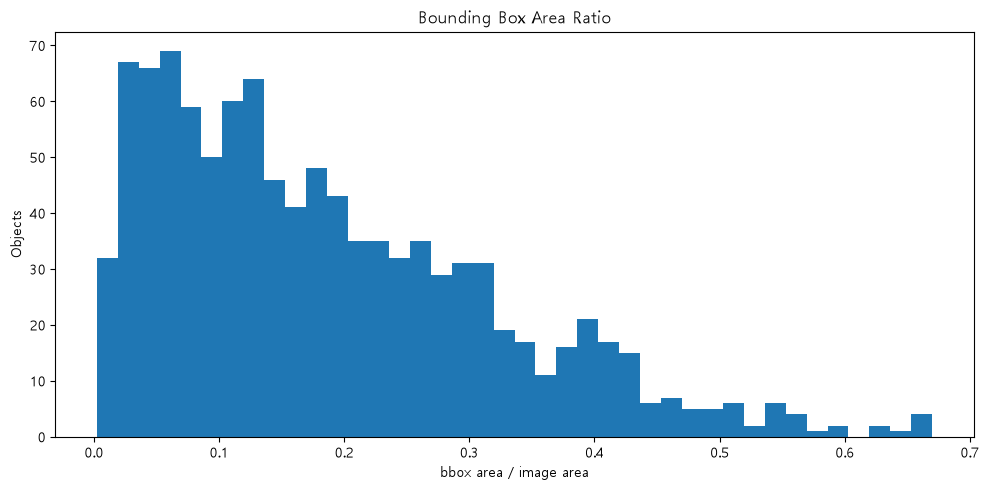

In [59]:
display(
    object_df["bbox_area_ratio"]
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame()
)

plt.figure(figsize=(10, 5))
plt.hist(object_df["bbox_area_ratio"], bins=40)
plt.xlabel("bbox area / image area")
plt.ylabel("Objects")
plt.title("Bounding Box Area Ratio")
plt.tight_layout()
plt.show()

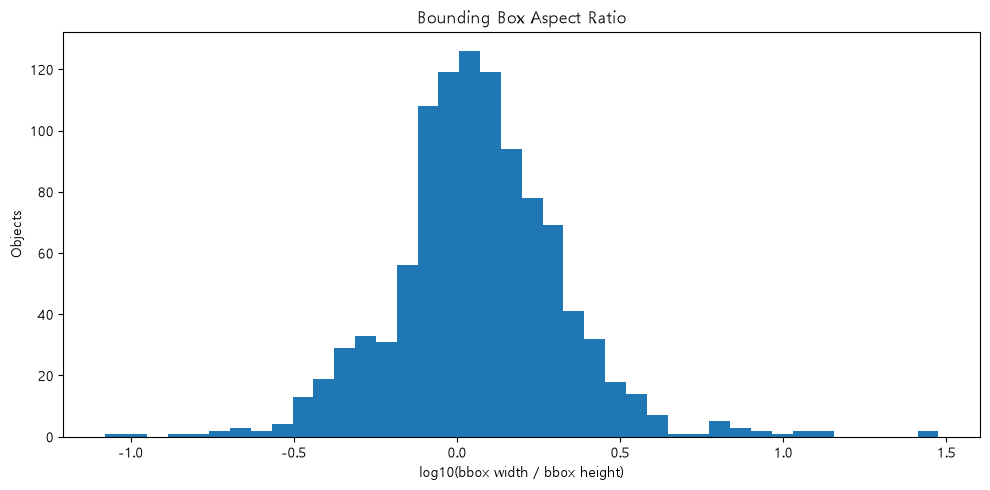

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10(object_df["bbox_aspect_ratio"].clip(lower=1e-6)), bins=40)
plt.xlabel("log10(bbox width / bbox height)")
plt.ylabel("Objects")
plt.title("Bounding Box Aspect Ratio")
plt.tight_layout()
plt.show()

# 19. 실제 객체 클래스 분포 확인

이 표는 폴더가 아니라 **JSON의 실제 객체 annotation**을 기준으로 셉니다.

한 이미지에 다른 학습 대상 객체가 추가로 들어 있으면 해당 클래스 객체 수가 늘어날 수 있습니다.
따라서 폴더 기준 이미지 균형과 객체 기준 균형은 서로 다를 수 있습니다.

In [61]:
object_support = (
    object_df[object_df["is_known_training_class"]]
    .groupby(["object_class", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Training", "Validation"], fill_value=0)
)

object_support["total"] = object_support["Training"] + object_support["Validation"]
object_support = object_support.sort_index()

display(object_support)

split,Training,Validation,total
object_class,,,
고철류/고철,13,2,15
고철류/골프채,9,2,11
고철류/기타,10,2,12
고철류/비철금속,9,2,11
고철류/전기프라이팬,9,2,11
고철류/주전자,9,3,12
고철류/철옷걸이,12,2,14
고철류/프라이팬,9,3,12
나무/기타,13,2,15


# 20. Train-Val 이미지 누수 검사

Validation은 모델이 학습하지 않은 데이터에서 성능을 보는 역할을 합니다.
그런데 Training과 Validation에 같은 이미지가 들어 있으면 모델이 이미 본 사진을 다시 평가하게 되어 성능이 실제보다 높아질 수 있습니다.

파일명이 다르더라도 이미지 bytes가 같을 수 있으므로 SHA-1 hash를 기준으로 검사합니다.

In [62]:
duplicate_groups = []
cross_split_duplicate_groups = []

for sha1, group in image_df.groupby("sha1"):
    if len(group) > 1:
        duplicate_groups.append(group[["split", "image_member", "sha1"]])

        if group["split"].nunique() > 1:
            cross_split_duplicate_groups.append(group[["split", "image_member", "sha1"]])

print("전체 exact duplicate 그룹:", len(duplicate_groups))
print("Train-Val exact duplicate 그룹:", len(cross_split_duplicate_groups))

if cross_split_duplicate_groups:
    display(pd.concat(cross_split_duplicate_groups, ignore_index=True))
else:
    print("Train-Val exact duplicate 없음: PASSED")

전체 exact duplicate 그룹: 0
Train-Val exact duplicate 그룹: 0
Train-Val exact duplicate 없음: PASSED


# 21. processed에 포함할 이미지 결정

기본 정책은 보수적으로 설정합니다.

## 제외하는 경우

1. 폴더 목표 클래스가 JSON에 없음
2. 학습 대상 86개 밖의 객체가 같이 존재함

두 번째 조건은 “모르는 객체를 그냥 background로 가르치는 상황”을 피하기 위한 안전장치입니다.
현재 업로드본에서 target 검사를 통과한 이미지에는 unknown 객체가 없지만, 이후 데이터가 바뀌어도 같은 코드가 안전하게 작동하도록 넣었습니다.

## 유지하는 객체

정상 이미지 안에서는 폴더 목표 객체만 남기는 것이 아니라 **JSON에 annotation된 모든 학습 대상 86개 객체**를 유지합니다.

In [63]:
def decide_keep_image(row):
    reasons = []

    if DROP_IF_TARGET_NOT_ANNOTATED and not bool(row["target_is_annotated"]):
        reasons.append("folder_target_not_in_json")

    if DROP_IF_UNKNOWN_OBJECT_EXISTS and int(row["unknown_object_count"]) > 0:
        reasons.append("unknown_object_exists")

    return len(reasons) == 0, ";".join(reasons)


decisions = image_df.apply(decide_keep_image, axis=1, result_type="expand")
image_df["keep_for_processed"] = decisions[0]
image_df["exclude_reason"] = decisions[1]

selection_summary = (
    image_df.groupby(["split", "keep_for_processed"])
    .size()
    .rename("images")
    .reset_index()
)

display(selection_summary)

excluded_df = image_df[~image_df["keep_for_processed"]].copy()

if len(excluded_df):
    display(
        excluded_df[
            [
                "split",
                "image_member",
                "folder_target_class",
                "exclude_reason",
            ]
        ]
    )

,split,keep_for_processed,images
0,Training,False,5
1,Training,True,761
2,Validation,False,1
3,Validation,True,165


,split,image_member,folder_target_class,exclude_reason
158,Training,Training/images/도기류/기타/14_X044_C045_0128/14_X0...,도기류/기타,folder_target_not_in_json;unknown_object_exists
160,Training,Training/images/도기류/기타/14_X047_C045_0128/14_X0...,도기류/기타,folder_target_not_in_json;unknown_object_exists
161,Training,Training/images/도기류/기타/14_X051_C045_0128/14_X0...,도기류/기타,folder_target_not_in_json;unknown_object_exists
250,Training,Training/images/비닐/기타/15_X071_C205_1206/15_X07...,비닐/기타,folder_target_not_in_json
251,Training,Training/images/비닐/기타/15_X071_C205_1206/15_X07...,비닐/기타,folder_target_not_in_json
807,Validation,Validation/images/도기류/병/14_X004_C163_1203/14_X...,도기류/병,folder_target_not_in_json


# 22. YOLO Detection 라벨 형식 이해하기

YOLO txt 한 줄은 다음 형식입니다.

```text
class_id x_center y_center width height
```

여기서 좌표는 픽셀이 아니라 **0~1 사이의 비율**입니다.

예를 들어 이미지 width가 1000px이고 bbox width가 200px이면:

```text
normalized width = 200 / 1000 = 0.2
```

정규화하는 이유는 이미지 해상도가 달라도 같은 방식으로 모델이 좌표를 다룰 수 있기 때문입니다.

In [64]:
def xyxy_to_yolo(x1, y1, x2, y2, image_width, image_height):
    """pixel xyxy bbox를 YOLO normalized xc,yc,w,h로 변환합니다."""
    x_center = ((x1 + x2) / 2.0) / image_width
    y_center = ((y1 + y2) / 2.0) / image_height
    box_width = (x2 - x1) / image_width
    box_height = (y2 - y1) / image_height

    return x_center, y_center, box_width, box_height

# 23. processed 폴더 생성

최종 학습 데이터 구조는 다음과 같습니다.

```text
../../data/processed/
├── images/
│   ├── train/
│   └── val/
├── labels/
│   ├── train/
│   └── val/
└── data.yaml
```

EDA와 전처리 과정에서 생성되는 CSV 보고서는 학습 데이터와 분리하여 다음 위치에 저장합니다.

```text
../models/yolo/01_experiment_augmentation/report/preprocess/
```

이렇게 분리하면 `processed`에는 모델이 직접 읽는 데이터만 남고,
분석용 CSV와 로그는 모델 실험 보고서 경로에서 한곳에 관리할 수 있습니다.

이미지는 다시 JPEG로 저장하지 않고 ZIP의 **원본 bytes를 그대로 복사**합니다.
따라서 이 과정 자체 때문에 이미지 품질이 떨어지지 않습니다.


In [65]:
# 기존 processed를 새로 만들기로 했다면 학습 데이터와 전처리 보고서를 함께 초기화합니다.
# 단, report/summary 등 2번 노트북의 모델 실험 결과는 건드리지 않습니다.
if PROCESSED_DIR.exists() and OVERWRITE_PROCESSED:
    shutil.rmtree(PROCESSED_DIR)

if REPORT_DIR.exists() and OVERWRITE_PROCESSED:
    shutil.rmtree(REPORT_DIR)

for split in ["train", "val"]:
    (PROCESSED_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (PROCESSED_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("processed 폴더 준비 완료:", PROCESSED_DIR)
print("전처리 보고서 폴더 준비 완료:", REPORT_DIR)


processed 폴더 준비 완료: C:\ai_challingers\recycling_ssg\data\processed
전처리 보고서 폴더 준비 완료: C:\ai_challingers\recycling_ssg\ai\models\yolo\01_experiment_augmentation\report\preprocess


# 24. 파일명 충돌 방지

현재 데이터에서는 이미지 basename이 겹치지 않지만, 앞으로 다른 데이터가 추가되면 같은 `sample.jpg` 이름이 여러 폴더에 있을 수 있습니다.

processed를 한 폴더로 평평하게(flat) 모으기 때문에 이름이 겹치면 덮어쓰기 문제가 생깁니다.

따라서:

- basename이 유일하면 원래 이름 유지
- 중복 basename이면 원본 ZIP 경로 hash를 prefix로 붙임

이 규칙으로 데이터가 늘어나도 안전하게 처리합니다.

In [66]:
basename_counts = Counter(image_df["image_name"])


def processed_image_name(image_member: str) -> str:
    basename = Path(image_member).name

    if basename_counts[basename] == 1:
        return basename

    short_hash = hashlib.sha1(image_member.encode("utf-8")).hexdigest()[:10]
    return f"{short_hash}__{basename}"

# 25. 실제 processed 생성

각 유지 이미지에 대해 다음 작업을 합니다.

1. 원본 JPG bytes 복사
2. 해당 JSON을 다시 읽음
3. 학습 대상 클래스 객체만 선택
4. BOX/POLYGON을 xyxy bbox로 변환
5. 실제 이미지 크기로 clip
6. YOLO normalized 좌표로 변환
7. `class_id xc yc w h` txt 저장

변환 과정 자체도 다시 보고서로 남깁니다.

In [67]:
processed_image_rows = []
processed_object_rows = []
preprocess_error_rows = []

keep_lookup = image_df.set_index("json_member")["keep_for_processed"].to_dict()
image_info_lookup = image_df.set_index("json_member").to_dict("index")

with zipfile.ZipFile(SOURCE_ZIP) as zf:
    for json_member in sorted(json_members):
        if not keep_lookup.get(json_member, False):
            continue

        info = image_info_lookup[json_member]
        source_split = info["split"]
        output_split = "train" if source_split == "Training" else "val"

        image_member = info["image_member"]
        output_name = processed_image_name(image_member)
        output_image_path = PROCESSED_DIR / "images" / output_split / output_name
        output_label_path = PROCESSED_DIR / "labels" / output_split / f"{Path(output_name).stem}.txt"

        raw_image = zf.read(image_member)
        output_image_path.write_bytes(raw_image)

        payload = json.load(zf.open(json_member))
        width = int(info["width"])
        height = int(info["height"])

        label_lines = []
        kept_object_count = 0

        for object_index, bounding in enumerate(payload.get("Bounding") or []):
            major = canonical_major(bounding.get("CLASS", "UNKNOWN"))
            detail = str(bounding.get("DETAILS", "UNKNOWN")).strip()
            class_name = f"{major}/{detail}"

            # 우리 86개 클래스 밖의 객체는 YOLO class id가 없으므로 사용하지 않습니다.
            if class_name not in CLASS_TO_ID:
                continue

            try:
                x1, y1, x2, y2, geometry = bounding_to_xyxy(bounding)

                x1 = float(np.clip(x1, 0, width))
                x2 = float(np.clip(x2, 0, width))
                y1 = float(np.clip(y1, 0, height))
                y2 = float(np.clip(y2, 0, height))

                if x2 <= x1 or y2 <= y1:
                    raise ValueError("clip 후 bbox가 유효하지 않습니다.")

                xc, yc, bw, bh = xyxy_to_yolo(
                    x1, y1, x2, y2,
                    image_width=width,
                    image_height=height,
                )

                normalized = np.array([xc, yc, bw, bh], dtype=float)

                if not np.all((normalized >= 0) & (normalized <= 1)):
                    raise ValueError(f"normalized bbox 범위 오류: {normalized.tolist()}")

                if bw <= 0 or bh <= 0:
                    raise ValueError("normalized width/height가 0 이하입니다.")

                class_id = CLASS_TO_ID[class_name]
                label_lines.append(
                    f"{class_id} {xc:.8f} {yc:.8f} {bw:.8f} {bh:.8f}"
                )

                kept_object_count += 1

                processed_object_rows.append({
                    "split": output_split,
                    "source_image_member": image_member,
                    "processed_image": output_name,
                    "class_id": class_id,
                    "class_name": class_name,
                    "source_geometry": geometry,
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "x_center_norm": xc,
                    "y_center_norm": yc,
                    "width_norm": bw,
                    "height_norm": bh,
                    "bbox_area_ratio": ((x2 - x1) * (y2 - y1)) / (width * height),
                })

            except Exception as error:
                preprocess_error_rows.append({
                    "json_member": json_member,
                    "image_member": image_member,
                    "object_index": object_index,
                    "error": repr(error),
                })

        output_label_path.write_text("\n".join(label_lines), encoding="utf-8")

        processed_image_rows.append({
            "split": output_split,
            "source_split": source_split,
            "source_image_member": image_member,
            "source_json_member": json_member,
            "processed_image": output_name,
            "processed_label": output_label_path.name,
            "folder_target_class": info["folder_target_class"],
            "width": width,
            "height": height,
            "objects": kept_object_count,
            "sha1": info["sha1"],
        })

processed_image_df = pd.DataFrame(processed_image_rows)
processed_object_df = pd.DataFrame(processed_object_rows)
preprocess_error_df = pd.DataFrame(preprocess_error_rows)

print("processed images :", len(processed_image_df))
print("processed objects:", len(processed_object_df))
print("conversion errors:", len(preprocess_error_df))

processed images : 926
processed objects: 1031
conversion errors: 0


# 26. `data.yaml` 생성

YOLO는 `data.yaml`을 통해 다음을 알게 됩니다.

- train 이미지 위치
- validation 이미지 위치
- 클래스 id와 이름

`path`는 현재 processed 절대경로로 기록합니다.
두 번째 노트북에서는 데이터 폴더가 이동했을 가능성까지 고려해 현재 경로로 다시 보정합니다.

In [68]:
data_yaml = {
    "path": str(PROCESSED_DIR.resolve()),
    "train": "images/train",
    "val": "images/val",
    "names": {class_id: class_name for class_id, class_name in ID_TO_CLASS.items()},
}

DATA_YAML_PATH = PROCESSED_DIR / "data.yaml"

with open(DATA_YAML_PATH, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        data_yaml,
        file,
        allow_unicode=True,
        sort_keys=False,
    )

print(DATA_YAML_PATH.read_text(encoding="utf-8")[:5000])

path: C:\ai_challingers\recycling_ssg\data\processed
train: images/train
val: images/val
names:
  0: 고철류/고철
  1: 고철류/골프채
  2: 고철류/기타
  3: 고철류/비철금속
  4: 고철류/전기프라이팬
  5: 고철류/주전자
  6: 고철류/철옷걸이
  7: 고철류/프라이팬
  8: 나무/기타
  9: 나무/나무행거
  10: 나무/도마
  11: 나무/액자
  12: 나무/장식품
  13: 나무/주걱
  14: 나무/주방용품
  15: 나무/포장재
  16: 도기류/그릇류
  17: 도기류/기타
  18: 도기류/뚝배기
  19: 도기류/받침
  20: 도기류/병
  21: 도기류/장식품
  22: 도기류/주전자
  23: 도기류/컵
  24: 도기류/항아리
  25: 도기류/화분
  26: 비닐/과자봉지
  27: 비닐/기타
  28: 비닐/리필용기
  29: 비닐/봉투
  30: 비닐/에어캡
  31: 비닐/일회용덮개
  32: 비닐/포장제
  33: 스티로폼/네모트레이
  34: 스티로폼/보호재
  35: 스티로폼/스티로폼
  36: 스티로폼/포장용기
  37: 유리병/기타
  38: 유리병/기타술병
  39: 유리병/맥주병
  40: 유리병/물병
  41: 유리병/박카스병
  42: 유리병/소주병
  43: 유리병/음료수병
  44: 유리병/주방용기
  45: 의류/기타
  46: 의류/기타의류
  47: 의류/레깅스
  48: 의류/면의류
  49: 의류/상의
  50: 의류/외투
  51: 의류/원피스
  52: 의류/하의
  53: 의류/합성섬유
  54: 종이류/기타
  55: 종이류/노트
  56: 종이류/상자류
  57: 종이류/신문지
  58: 종이류/신발상자
  59: 종이류/음료수곽
  60: 종이류/종이봉투
  61: 종이류/책자
  62: 종이류/포장상자
  63: 캔류/기타
  64: 캔류/맥주캔
  65: 캔류/스팸류
  66: 캔류/음료수

# 27. processed용 보고서 CSV 저장

이 보고서들은 “어떤 데이터로 모델을 학습했는가?”를 나중에 다시 추적할 수 있게 해줍니다.

특히 팀 프로젝트에서는 모델 성능 숫자만 남기기보다 **학습 데이터 버전과 제외 사유를 함께 기록**하는 것이 중요합니다.

In [69]:
class_mapping_df = pd.DataFrame({
    "class_id": range(len(CLASS_NAMES)),
    "class_name": CLASS_NAMES,
})

processed_support_df = (
    processed_object_df
    .groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "val"], fill_value=0)
    .reindex(CLASS_NAMES, fill_value=0)
)

processed_support_df["total"] = processed_support_df["train"] + processed_support_df["val"]
processed_support_df = processed_support_df.reset_index()

image_df.to_csv(REPORT_DIR / "raw_image_audit.csv", index=False, encoding="utf-8-sig")
object_df.to_csv(REPORT_DIR / "raw_object_audit.csv", index=False, encoding="utf-8-sig")
issue_df.to_csv(REPORT_DIR / "raw_issues.csv", index=False, encoding="utf-8-sig")
excluded_df.to_csv(REPORT_DIR / "excluded_images.csv", index=False, encoding="utf-8-sig")
processed_image_df.to_csv(REPORT_DIR / "processed_images.csv", index=False, encoding="utf-8-sig")
processed_object_df.to_csv(REPORT_DIR / "processed_objects.csv", index=False, encoding="utf-8-sig")
preprocess_error_df.to_csv(REPORT_DIR / "preprocess_errors.csv", index=False, encoding="utf-8-sig")
class_mapping_df.to_csv(REPORT_DIR / "class_mapping.csv", index=False, encoding="utf-8-sig")
processed_support_df.to_csv(REPORT_DIR / "class_support_processed.csv", index=False, encoding="utf-8-sig")

print("보고서 저장 위치:", REPORT_DIR)
for path in sorted(REPORT_DIR.glob("*.csv")):
    print("-", path.name)

보고서 저장 위치: C:\ai_challingers\recycling_ssg\ai\models\yolo\01_experiment_augmentation\report\preprocess
- class_mapping.csv
- class_support_processed.csv
- excluded_images.csv
- preprocess_errors.csv
- processed_images.csv
- processed_objects.csv
- raw_image_audit.csv
- raw_issues.csv
- raw_object_audit.csv


# 28. processed 최종 규모 확인

원본 수와 processed 수가 다른 이유를 반드시 확인합니다.

현재 정책에서는 폴더 목표 라벨이 JSON에 없는 의심 샘플이 제외되므로 processed가 원본보다 조금 작아지는 것이 정상입니다.

In [70]:
processed_summary = (
    processed_image_df
    .groupby("split")
    .agg(
        images=("processed_image", "count"),
        objects=("objects", "sum"),
        unique_target_classes=("folder_target_class", "nunique"),
    )
    .reindex(["train", "val"])
)

display(processed_summary)

display(processed_support_df)

print("Validation 객체가 0개인 클래스")
display(
    processed_support_df[
        processed_support_df["val"].eq(0)
    ][["class_name", "train", "val"]]
)

,images,objects,unique_target_classes
split,,,
train,761,853,86
val,165,178,83


split,class_name,train,val,total
0,고철류/고철,13,2,15
1,고철류/골프채,9,2,11
2,고철류/기타,10,2,12
3,고철류/비철금속,9,2,11
4,고철류/전기프라이팬,9,2,11
5,고철류/주전자,9,3,12
6,고철류/철옷걸이,12,2,14
7,고철류/프라이팬,9,3,12
8,나무/기타,13,2,15
9,나무/나무행거,9,2,11


Validation 객체가 0개인 클래스


split,class_name,train,val
45,의류/기타,5,0
63,캔류/기타,5,0
80,형광등/기타,14,0


# 29. processed 파일 1:1 대응 검사

모든 processed 이미지에는 같은 stem의 label txt가 있어야 합니다.

예:

```text
images/train/A.jpg
labels/train/A.txt
```

이 단계에서 하나라도 빠져 있으면 학습 전에 중단합니다.

In [71]:
file_pair_errors = []

for split in ["train", "val"]:
    image_paths = sorted((PROCESSED_DIR / "images" / split).glob("*"))
    label_paths = sorted((PROCESSED_DIR / "labels" / split).glob("*.txt"))

    image_stems = {path.stem for path in image_paths if path.is_file()}
    label_stems = {path.stem for path in label_paths if path.is_file()}

    missing_labels = sorted(image_stems - label_stems)
    missing_images = sorted(label_stems - image_stems)

    for stem in missing_labels:
        file_pair_errors.append((split, stem, "missing_label"))

    for stem in missing_images:
        file_pair_errors.append((split, stem, "missing_image"))

    print(
        split,
        "images=", len(image_stems),
        "labels=", len(label_stems),
        "missing_labels=", len(missing_labels),
        "missing_images=", len(missing_images),
    )

if file_pair_errors:
    display(pd.DataFrame(file_pair_errors, columns=["split", "stem", "error"]))
    raise ValueError("processed 이미지-label 1:1 대응 오류가 있습니다.")

print("Image-label pairing: PASSED")

train images= 761 labels= 761 missing_labels= 0 missing_images= 0
val images= 165 labels= 165 missing_labels= 0 missing_images= 0
Image-label pairing: PASSED


# 30. YOLO txt를 다시 읽어서 범위 검사

전처리 코드가 txt를 만들었다고 끝이 아닙니다.
최종 저장된 파일을 다시 읽어 다음을 확인합니다.

- 한 줄이 5개 값인지
- class id가 0~85 범위인지
- 좌표가 모두 0~1인지
- width / height가 0보다 큰지

이것은 “생성 코드”와 “최종 파일” 사이의 마지막 안전검사입니다.

In [72]:
label_validation_errors = []
label_object_count = 0

for split in ["train", "val"]:
    for label_path in sorted((PROCESSED_DIR / "labels" / split).glob("*.txt")):
        text = label_path.read_text(encoding="utf-8").strip()

        if not text:
            label_validation_errors.append({
                "split": split,
                "label": str(label_path),
                "error": "empty_label",
            })
            continue

        for line_number, line in enumerate(text.splitlines(), 1):
            try:
                parts = line.split()

                if len(parts) != 5:
                    raise ValueError(f"5개 값이 아니라 {len(parts)}개 값")

                class_value, xc, yc, bw, bh = map(float, parts)
                class_id = int(class_value)

                if class_value != class_id:
                    raise ValueError("class id가 정수가 아님")

                if class_id not in ID_TO_CLASS:
                    raise ValueError(f"알 수 없는 class id={class_id}")

                coords = np.array([xc, yc, bw, bh], dtype=float)

                if not np.all((coords >= 0) & (coords <= 1)):
                    raise ValueError(f"0~1 범위를 벗어난 좌표: {coords.tolist()}")

                if bw <= 0 or bh <= 0:
                    raise ValueError("bbox width/height가 0 이하")

                label_object_count += 1

            except Exception as error:
                label_validation_errors.append({
                    "split": split,
                    "label": str(label_path),
                    "line": line_number,
                    "content": line,
                    "error": repr(error),
                })

print("YOLO txt에서 다시 읽은 객체 수:", label_object_count)
print("라벨 검증 오류 수:", len(label_validation_errors))

if label_validation_errors:
    display(pd.DataFrame(label_validation_errors).head(50))
    raise ValueError("processed YOLO label 검증 오류가 있습니다.")

print("YOLO label validation: PASSED")

YOLO txt에서 다시 읽은 객체 수: 1031
라벨 검증 오류 수: 0
YOLO label validation: PASSED


# 31. processed Train-Val 누수 다시 검사

원본에서 중복이 없더라도 processed 생성 후 다시 확인합니다.
이번에는 이미 계산한 SHA-1을 사용합니다.

In [73]:
processed_cross_split_dups = (
    processed_image_df
    .groupby("sha1")
    .filter(lambda group: group["split"].nunique() > 1)
)

print("processed Train-Val exact duplicate rows:", len(processed_cross_split_dups))

if len(processed_cross_split_dups):
    display(processed_cross_split_dups)
    raise ValueError("processed Train-Val 데이터 누수가 있습니다.")

print("Processed leakage check: PASSED")

processed Train-Val exact duplicate rows: 0
Processed leakage check: PASSED


# 32. YOLO txt bbox를 다시 픽셀 좌표로 복원하는 함수

마지막으로 실제 이미지 위에 bbox를 그려 봅니다.

YOLO txt는 정규화 좌표이므로 시각화를 위해 다시 pixel 좌표로 복원해야 합니다.

In [74]:
def read_yolo_label_as_xyxy(label_path: Path, image_width: int, image_height: int):
    classes = []
    boxes = []

    text = label_path.read_text(encoding="utf-8").strip()

    for line in text.splitlines():
        class_id, xc, yc, bw, bh = map(float, line.split())
        class_id = int(class_id)

        x1 = (xc - bw / 2) * image_width
        y1 = (yc - bh / 2) * image_height
        x2 = (xc + bw / 2) * image_width
        y2 = (yc + bh / 2) * image_height

        classes.append(class_id)
        boxes.append([x1, y1, x2, y2])

    return np.asarray(classes, dtype=int), np.asarray(boxes, dtype=np.float32).reshape(-1, 4)


def draw_boxes(image_bgr, classes, boxes):
    output = image_bgr.copy()

    for class_id, box in zip(classes, boxes):
        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # OpenCV 기본 폰트는 한글 지원이 제한적이라 이미지에는 class id만 표시합니다.
        cv2.putText(
            output,
            str(class_id),
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    return output

# 33. processed bbox 샘플 눈으로 확인

Train / Validation 각각 여러 장을 랜덤하게 골라 실제 bbox를 확인합니다.

확인 포인트:

- bbox가 실제 객체를 감싸는가?
- 완전히 엉뚱한 곳에 그려지지 않았는가?
- 너무 크거나 너무 작게 변환되지 않았는가?
- class id와 표의 class name이 맞는가?

TRAIN


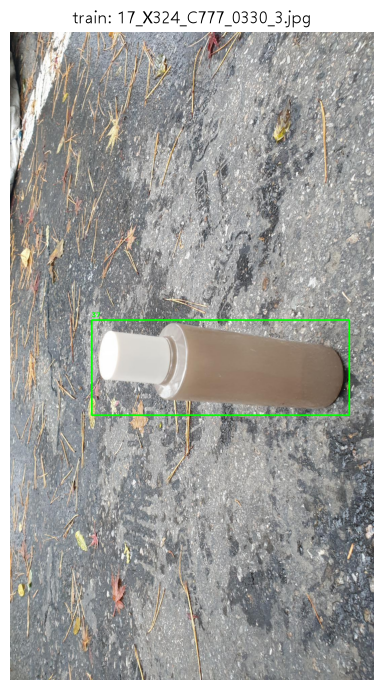

,class_id,class_name
0,37,유리병/기타


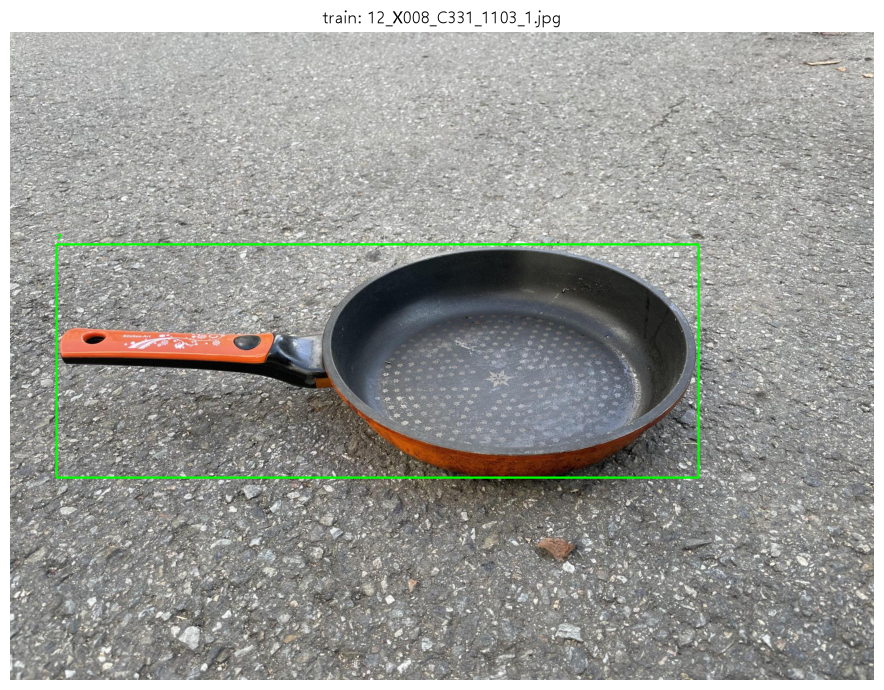

,class_id,class_name
0,7,고철류/프라이팬


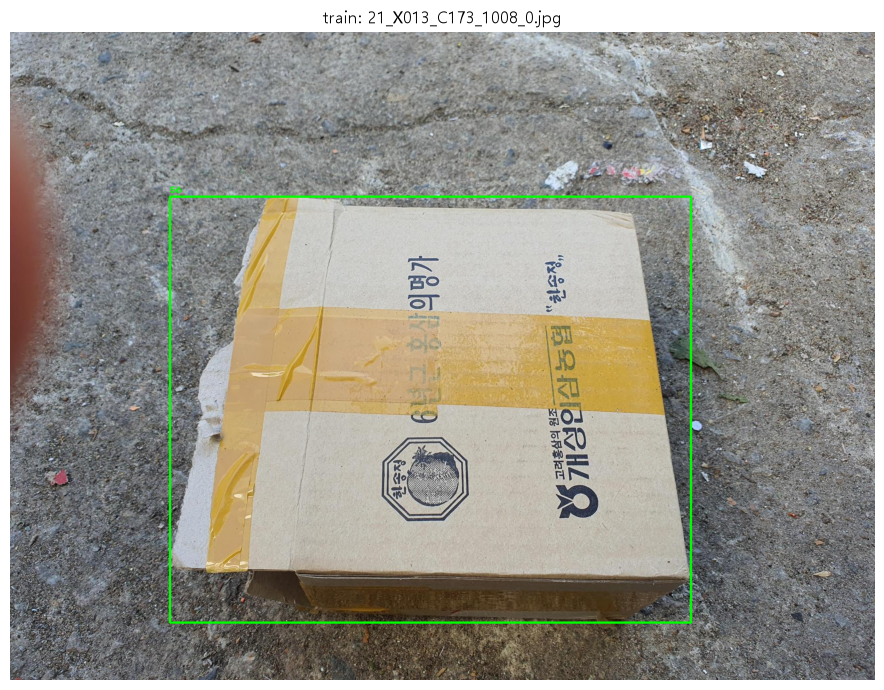

,class_id,class_name
0,56,종이류/상자류


In [ ]:
NUM_VISUAL_SAMPLES_PER_SPLIT = 4
rng = np.random.default_rng(SEED)

for split in ["train", "val"]:
    split_rows = processed_image_df[processed_image_df["split"].eq(split)]
    sample_count = min(NUM_VISUAL_SAMPLES_PER_SPLIT, len(split_rows))
    sample_indices = rng.choice(split_rows.index.to_numpy(), size=sample_count, replace=False)

    print("=" * 90)
    print(split.upper())

    for index in sample_indices:
        row = processed_image_df.loc[index]

        image_path = PROCESSED_DIR / "images" / split / row["processed_image"]
        label_path = PROCESSED_DIR / "labels" / split / row["processed_label"]

        image = cv2.imread(str(image_path))
        height, width = image.shape[:2]
        classes, boxes = read_yolo_label_as_xyxy(label_path, width, height)
        drawn = draw_boxes(image, classes, boxes)

        plt.figure(figsize=(10, 7))
        plt.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
        plt.title(f"{split}: {row['processed_image']}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        display(pd.DataFrame({
            "class_id": classes,
            "class_name": [ID_TO_CLASS[int(class_id)] for class_id in classes],
        }))

# 34. processed 클래스 분포 시각화

이 그래프는 **최종 모델이 실제로 학습하게 될 객체 수**입니다.

특히 Validation 객체가 0인 클래스는 해당 Validation set만으로는 그 클래스 AP를 제대로 평가할 수 없습니다.
두 번째 노트북에서는 전체 mAP와 함께 클래스별 support를 항상 같이 표시합니다.

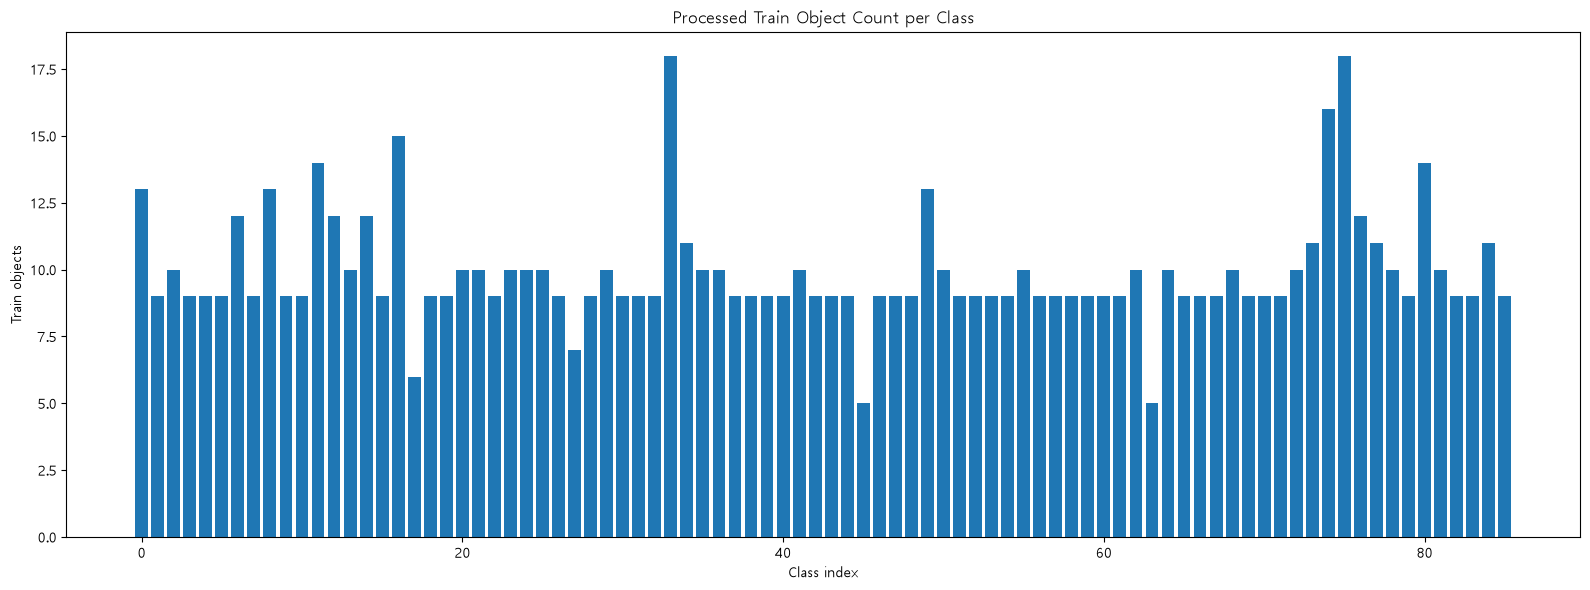

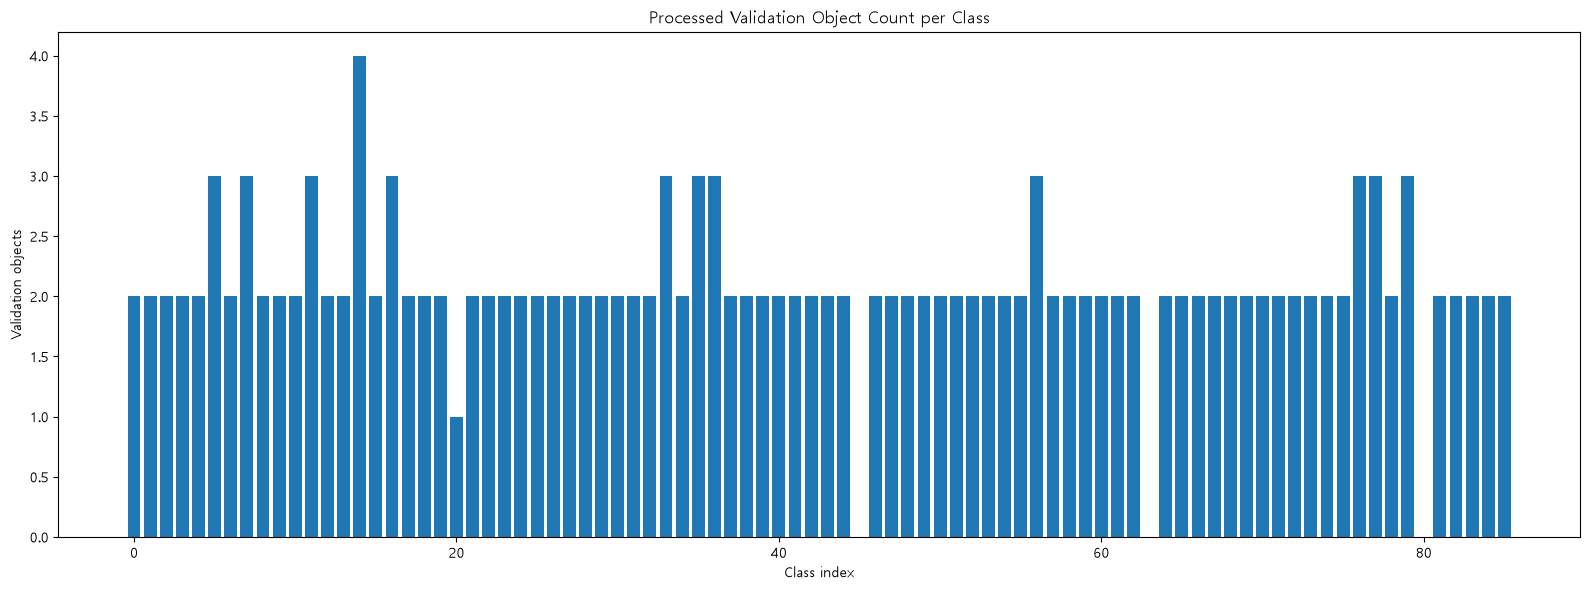

In [ ]:
plot_df = processed_support_df.copy()

plt.figure(figsize=(16, 6))
plt.bar(np.arange(len(plot_df)), plot_df["train"])
plt.xlabel("Class index")
plt.ylabel("Train objects")
plt.title("Processed Train Object Count per Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
plt.bar(np.arange(len(plot_df)), plot_df["val"])
plt.xlabel("Class index")
plt.ylabel("Validation objects")
plt.title("Processed Validation Object Count per Class")
plt.tight_layout()
plt.show()

# 35. EDA / 전처리 요약 파일 만들기

사람이 읽기 쉬운 한 줄 요약 CSV도 저장합니다.
이 파일은 두 번째 노트북에서 “어떤 processed를 사용했는지” 확인할 때 사용할 수 있습니다.

In [ ]:
summary_rows = [
    {"key": "source_zip", "value": str(SOURCE_ZIP)},
    {"key": "raw_images", "value": len(image_df)},
    {"key": "raw_objects", "value": len(object_df)},
    {"key": "training_classes", "value": len(CLASS_NAMES)},
    {"key": "raw_training_images", "value": int((image_df["split"] == "Training").sum())},
    {"key": "raw_validation_images", "value": int((image_df["split"] == "Validation").sum())},
    {"key": "excluded_images", "value": len(excluded_df)},
    {"key": "processed_train_images", "value": int((processed_image_df["split"] == "train").sum())},
    {"key": "processed_val_images", "value": int((processed_image_df["split"] == "val").sum())},
    {"key": "processed_train_objects", "value": int((processed_object_df["split"] == "train").sum())},
    {"key": "processed_val_objects", "value": int((processed_object_df["split"] == "val").sum())},
    {"key": "polygon_to_bbox_objects", "value": int((processed_object_df["source_geometry"] == "POLYGON->BOX").sum())},
    {"key": "preprocess_errors", "value": len(preprocess_error_df)},
    {"key": "val_classes_without_objects", "value": int((processed_support_df["val"] == 0).sum())},
]

preprocess_summary_df = pd.DataFrame(summary_rows)
preprocess_summary_df.to_csv(
    REPORT_DIR / "preprocess_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(preprocess_summary_df)

,key,value
0,source_zip,C:\ai_challingers\recycling_ssg\data\sample\tr...
1,raw_images,932
2,raw_objects,1040
3,training_classes,86
4,raw_training_images,766
5,raw_validation_images,166
6,excluded_images,6
7,processed_train_images,761
8,processed_val_images,165
9,processed_train_objects,853


# 36. 최종 폴더 트리 확인

이 셀에서 보이는 구조가 두 번째 노트북의 입력이 됩니다.

In [ ]:
def print_tree(root: Path, max_depth=3):
    root = root.resolve()
    print(root.name + "/")

    for path in sorted(root.rglob("*")):
        relative = path.relative_to(root)

        if len(relative.parts) > max_depth:
            continue

        indent = "    " * (len(relative.parts) - 1)
        suffix = "/" if path.is_dir() else ""
        print(f"{indent}├── {path.name}{suffix}")


print_tree(PROCESSED_DIR, max_depth=3)

processed/
├── data.yaml
├── images/
    ├── train/
        ├── 12_X001_C022_0928_0.jpg
        ├── 12_X001_C024_1123_1.jpg
        ├── 12_X001_C055_0131_1.jpg
        ├── 12_X001_C058_0202_2.jpg
        ├── 12_X001_C162_1111_2.jpg
        ├── 12_X001_C163_0108_4.jpg
        ├── 12_X001_C169_1102_1.jpg
        ├── 12_X001_C171_1007_3.jpg
        ├── 12_X001_C190_1113_3.jpg
        ├── 12_X001_C205_1005_1.jpg
        ├── 12_X001_C211_1208_3.jpg
        ├── 12_X001_C331_1210_4.jpg
        ├── 12_X001_C333_1110_2.jpg
        ├── 12_X002_C023_1211_4.jpg
        ├── 12_X002_C194_1023_0.jpg
        ├── 12_X002_C331_1127_3.jpg
        ├── 12_X003_C044_1105_0.jpg
        ├── 12_X003_C163_1202_2.jpg
        ├── 12_X004_C026_0924_0.jpg
        ├── 12_X004_C055_1027_4.jpg
        ├── 12_X005_C015_1119_4.jpg
        ├── 12_X005_C187_1023_1.jpg
        ├── 12_X005_C189_1123_0.jpg
        ├── 12_X005_C323_0201_3.jpg
        ├── 12_X006_C055_0131_3.jpg
        ├── 12_X006_C163_1207_0.jpg
        ├── 

# 37. 전처리 결과 해석

## 이 노트북에서 의도적으로 하지 않은 것

### 1) 이미지 resize를 processed에 영구 적용하지 않음

YOLO 학습 단계에서 `imgsz`에 맞춰 처리합니다.
원본을 보존해야 나중에 640, 768 등 다른 입력 크기도 실험할 수 있습니다.

### 2) 이미지 증강을 하지 않음

증강은 모델 성능에 직접 영향을 주는 실험 변수입니다.
원본 전처리 단계에 섞으면 어떤 증강이 효과가 있었는지 비교하기 어려워집니다.

### 3) 폴더명을 무조건 정답으로 덮어쓰지 않음

JSON annotation과 모순되는 샘플은 임의 수정하지 않고 제외 및 보고합니다.

### 4) Validation을 증강하거나 Training에 합치지 않음

Validation은 학습하지 않은 데이터로 일반화 성능을 보기 위한 데이터입니다.
두 번째 노트북에서도 Validation에는 증강을 적용하지 않습니다.

---

## 다음 단계

두 번째 노트북에서 `../../data/processed`의 이 폴더를 읽습니다.

```text
data/processed/
```

그리고 동일한 processed 데이터로:

1. YOLO baseline
2. YOLO 내장 augmentation 개별 실험
3. OpenCV augmentation 개별 실험
4. 여러 증강 조합 실험
5. 모든 Precision / Recall / mAP 비교
6. 상위 조합 multi-seed 재검증

을 수행합니다.

# 38. 전처리 완료 체크리스트

아래 조건을 모두 만족하면 두 번째 노트북으로 넘어가도 됩니다.

- [ ] 원본 이미지와 JSON 개수를 확인했다.
- [ ] Training/Validation 클래스 수를 확인했다.
- [ ] 폴더 목표 클래스와 JSON 불일치 샘플을 확인했다.
- [ ] BOX/POLYGON을 모두 처리했다.
- [ ] 깨진 이미지가 없는지 확인했다.
- [ ] Train-Val exact duplicate를 확인했다.
- [ ] processed 이미지-label 파일이 1:1 대응한다.
- [ ] 모든 YOLO 좌표가 0~1 범위다.
- [ ] class id가 `data.yaml`과 일치한다.
- [ ] 실제 bbox 시각화를 확인했다.
- [ ] `preprocess_errors.csv`가 비어 있거나 사유를 검토했다.
- [ ] `../../data/processed/data.yaml`이 생성되었다.

이제 `02_yolo_baseline_augmentation_search.ipynb`를 실행하면 됩니다.